In [ ]:
!pip install huggingface_hub[hf_xet]
!pip install hf_xet
!pip install -q datasets==2.16.1


In [ ]:
!pip install -q datasets==2.16.1 transformers


In [ ]:
!pip install datasets

In [59]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, AutoConfig
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
import torch
from transformers import DataCollatorWithPadding
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset, DatasetDict
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline, BertTokenizer, BertModel
from sklearn.decomposition import PCA


## Load the Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/Datafiniti_May19.csv"
df = pd.read_csv(file_path)


Mounted at /content/drive


In [ ]:
df_cp = df.copy()

In [ ]:
df_cp.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [ ]:
df_cp.isnull().sum()

,0
id,0
dateAdded,0
dateUpdated,0
name,0
asins,0
brand,0
categories,0
primaryCategories,0
imageURLs,0
keys,0


In [ ]:
df_cp.shape

(28332, 24)

In [ ]:
df_cp.columns

Index(['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand',
       'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer',
       'manufacturerNumber', 'reviews.date', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs'],
      dtype='object')

# Task 0. Preprocessing. Map Star Ratings to Sentiment Classes

### Clean the data

In [ ]:
# Choose columns
df_cp = df_cp[['name', 'brand', 'categories', 'primaryCategories','reviews.rating', 'reviews.text']]

print(df_cp.head())

                                                name         brand  \
0  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
1  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
2  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
3  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
4  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   

                                          categories primaryCategories  \
0  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
1  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
2  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
3  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
4  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   

   reviews.rating                                       reviews.text  
0               3  I order 3 of them and one of the item is bad

In [ ]:
# cleaning NaN from text
df_cp = df_cp[df_cp['reviews.text'].notna() & (df_cp['reviews.text'].str.strip() != '')]

In [ ]:
# cleaning NaN from rating
df_cp = df_cp[df_cp['reviews.rating'].notna()]

In [ ]:
# Check Null after cleaning
print(df_cp.isnull().sum())

print(df_cp.shape)
print(df_cp.head())

name                 0
brand                0
categories           0
primaryCategories    0
reviews.rating       0
reviews.text         0
dtype: int64
(28332, 6)
                                                name         brand  \
0  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
1  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
2  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
3  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   
4  AmazonBasics AAA Performance Alkaline Batterie...  Amazonbasics   

                                          categories primaryCategories  \
0  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
1  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
2  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
3  AA,AAA,Health,Electronics,Health & Household,C...   Health & Beauty   
4  AA,AAA,Health,Electronics,Health & Household

### Map Star Ratings to Sentiment Classes

In [ ]:
# Mapping Star Ratings to Sentiment Classes
def map_sentiment(rating):
    if rating <= 2:
        return 'NEGATIVE'
    elif rating == 3:
        return 'NEUTRAL'
    else:
        return 'POSITIVE'

df_cp['sentiment'] = df_cp['reviews.rating'].apply(map_sentiment)


In [ ]:
df_cp[['reviews.rating', 'sentiment']].head()

,reviews.rating,sentiment
0,3,NEUTRAL
1,4,POSITIVE
2,5,POSITIVE
3,5,POSITIVE
4,5,POSITIVE


In [ ]:
df_cp[['reviews.text', 'sentiment']].head()

,reviews.text,sentiment
0,I order 3 of them and one of the item is bad q...,NEUTRAL
1,Bulk is always the less expensive way to go fo...,POSITIVE
2,Well they are not Duracell but for the price i...,POSITIVE
3,Seem to work as well as name brand batteries a...,POSITIVE
4,These batteries are very long lasting the pric...,POSITIVE


In [ ]:
# Display 6 samples
df_cp[['reviews.rating', 'sentiment']].sample(6)

,reviews.rating,sentiment
9087,5,POSITIVE
5116,5,POSITIVE
8709,2,NEGATIVE
21861,4,POSITIVE
17348,5,POSITIVE
5485,5,POSITIVE


In [ ]:
df_cp.isnull().sum()

,0
name,0
brand,0
categories,0
primaryCategories,0
reviews.rating,0
reviews.text,0
sentiment,0


### Data balancing


In [ ]:
sentiment_counts = df_cp['sentiment'].value_counts()
sentiment_percentages = df_cp['sentiment'].value_counts(normalize=True) * 100

print(sentiment_counts)
print("\n Percentage: ")
print(sentiment_percentages)


sentiment
POSITIVE    25545
NEGATIVE     1581
NEUTRAL      1206
Name: count, dtype: int64

 Percentage: 
sentiment
POSITIVE    90.163066
NEGATIVE     5.580263
NEUTRAL      4.256671
Name: proportion, dtype: float64


In [ ]:
# Balance the dataset using oversampling
df_ps = df_cp[df_cp['sentiment'] == 'POSITIVE']
df_ng = df_cp[df_cp['sentiment'] == 'NEGATIVE']
df_nt = df_cp[df_cp['sentiment'] == 'NEUTRAL']

max_count = max(len(df_ps), len(df_ng), len(df_nt)) # take max samples

upsampled_ps = resample(df_ps, replace=True, n_samples=max_count, random_state=42)
upsampled_ng = resample(df_ng, replace=True, n_samples=max_count, random_state=42)
upsampled_nt = resample(df_nt, replace=True, n_samples=max_count, random_state=42)

# concatenate
df_balanced = pd.concat([upsampled_ps, upsampled_ng, upsampled_nt])

print(df_balanced['sentiment'].value_counts())

sentiment
POSITIVE    25545
NEGATIVE    25545
NEUTRAL     25545
Name: count, dtype: int64


### Visiualization

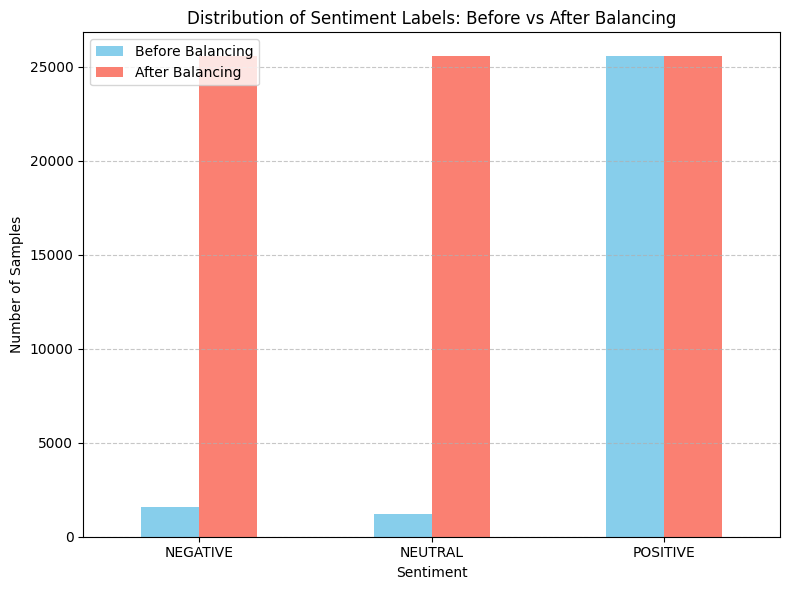

In [ ]:
# Count samples per sentiment before balancing
before_counts = df_cp['sentiment'].value_counts().sort_index()
# Count samples per sentiment after balancing
after_counts = df_balanced['sentiment'].value_counts().sort_index()

# Create a DataFrame to compare the counts
import pandas as pd
compare_df = pd.DataFrame({
    'Before Balancing': before_counts,
    'After Balancing': after_counts
})

# Plot the comparison as a bar chart
compare_df.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])
plt.title('Distribution of Sentiment Labels: Before vs After Balancing')
plt.xlabel('Sentiment')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
df_cp = df_balanced.copy()

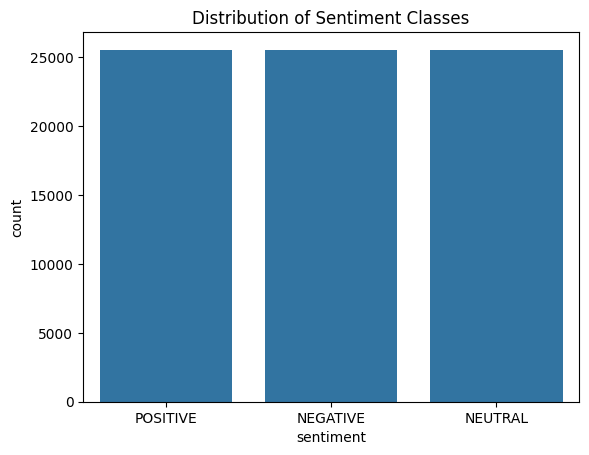

In [ ]:
sns.countplot(x='sentiment', data=df_balanced)
plt.title('Distribution of Sentiment Classes')
plt.show()

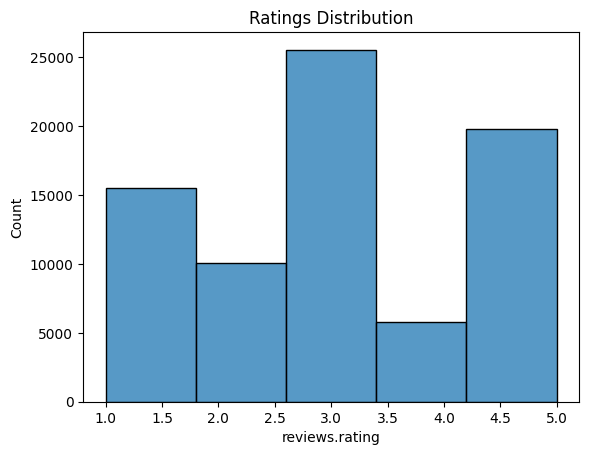

In [ ]:
sns.histplot(df_cp['reviews.rating'], bins=5)
plt.title('Ratings Distribution')
plt.show()

In [ ]:
# calculates the number of words in each review and stores it in a new column called word_count. This help us in training
df_cp['word_count'] = df_cp['reviews.text'].apply(lambda x: len(str(x).split()))

In [ ]:
print(df_cp.columns)

Index(['name', 'brand', 'categories', 'primaryCategories', 'reviews.rating',
       'reviews.text', 'sentiment', 'word_count'],
      dtype='object')


# Task 1. Classification with pre-trained models.

### Splitting

In [ ]:
# split tha data
# 70% for training , 20% for test , 10% for validation
train, test = train_test_split(df_cp, test_size=0.3, stratify=df_cp['sentiment'])
test, validation = train_test_split(test, test_size=1/3, stratify=test['sentiment'])

In [ ]:
train.shape, validation.shape, test.shape

((53644, 8), (7664, 8), (15327, 8))

In [ ]:
# Selecting Important Columns
subset_of_columns = ['reviews.text', 'sentiment', 'reviews.rating', 'word_count']
train = train[subset_of_columns]
validation = validation[subset_of_columns]
test = test[subset_of_columns]

#^ By selecting only these columns, I simplify the dataset and remove any irrelevant data that could distract from the model's training and evaluation.

In [ ]:
# converted the Pandas DataFrames (train, validation, test) into the format required by the datasets library,
# which is optimized for working with NLP tasks and Hugging Face models.
# Create HuggingFace Datasets
dataset = DatasetDict({
    'train': Dataset.from_pandas(train, preserve_index=False),
    'validation': Dataset.from_pandas(validation, preserve_index=False),
    'test': Dataset.from_pandas(test, preserve_index=False)
})


In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['reviews.text', 'sentiment', 'reviews.rating', 'word_count'],
        num_rows: 53644
    })
    validation: Dataset({
        features: ['reviews.text', 'sentiment', 'reviews.rating', 'word_count'],
        num_rows: 7664
    })
    test: Dataset({
        features: ['reviews.text', 'sentiment', 'reviews.rating', 'word_count'],
        num_rows: 15327
    })
})


### Tokenization

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(example):
    tokenized = tokenizer(example['reviews.text'], padding=True, truncation=True, max_length=128)
    tokenized["labels"] = [label_to_id[label] for label in example["sentiment"]]
    return tokenized

In [ ]:
# creates two dictionaries to convert between text labels ("NEGATIVE", "NEUTRAL", "POSITIVE") and their corresponding IDs (0, 1, 2).

label_to_id = {label: idx for idx, label in enumerate(['NEGATIVE', 'NEUTRAL', 'POSITIVE'])} #used to convert text labels to IDs for model training.
id_to_label = {idx: label for label, idx in label_to_id.items()} # used to convert IDs to text labels for prediction or display.

print(label_to_id)
print(id_to_label)


{'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
{0: 'NEGATIVE', 1: 'NEUTRAL', 2: 'POSITIVE'}


In [ ]:
tokenized_datasets = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/53644 [00:00<?, ? examples/s]

Map:   0%|          | 0/7664 [00:00<?, ? examples/s]

Map:   0%|          | 0/15327 [00:00<?, ? examples/s]

In [ ]:
sentiment_encoded = tokenized_datasets.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/53644 [00:00<?, ? examples/s]

Map:   0%|          | 0/7664 [00:00<?, ? examples/s]

Map:   0%|          | 0/15327 [00:00<?, ? examples/s]

## Build distilbert model

In [ ]:
!pip install evaluate

In [ ]:
# Load Pretrained Model with config
num_labels = len(label_to_id)
model_ckpt = "distilbert-base-uncased"

config = AutoConfig.from_pretrained(model_ckpt, num_labels=num_labels, label_to_id=label_to_id, id_to_label=id_to_label)

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config)
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import evaluate
import numpy as np
# Define metrics
accuracy = evaluate.load("accuracy")

def compute_metrics_evaluate(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

### Train the model

In [ ]:
# Define Trainer
training_args = TrainingArguments(
    output_dir="./results-distilbert",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=sentiment_encoded["train"],
    eval_dataset=sentiment_encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

<ipython-input-42-f2b8bbe86e61>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nthn9819 (nthn9819-github) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.082500,0.072922,0.981602,0.981592
2,0.026600,0.039157,0.989170,0.989162
3,0.008700,0.031669,0.994259,0.994253


TrainOutput(global_step=10059, training_loss=0.08370900669040067, metrics={'train_runtime': 532.6819, 'train_samples_per_second': 302.117, 'train_steps_per_second': 18.884, 'total_flos': 5329655895278592.0, 'train_loss': 0.08370900669040067, 'epoch': 3.0})

### Evaluate

In [ ]:
# Evaluate
preds_distil = trainer.predict(sentiment_encoded["test"])
preds_distil.metrics

{'test_loss': 0.03278994932770729,
 'test_accuracy': 0.993997520715078,
 'test_f1': 0.9939915188552204,
 'test_runtime': 15.8712,
 'test_samples_per_second': 965.713,
 'test_steps_per_second': 60.361}

In [ ]:
y_pred_distil = np.argmax(preds_distil.predictions, axis=1)
y_true_distil = sentiment_encoded["test"][:]["labels"]

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true_distil, y_pred_distil))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5109
           1       0.99      1.00      0.99      5109
           2       1.00      0.98      0.99      5109

    accuracy                           0.99     15327
   macro avg       0.99      0.99      0.99     15327
weighted avg       0.99      0.99      0.99     15327



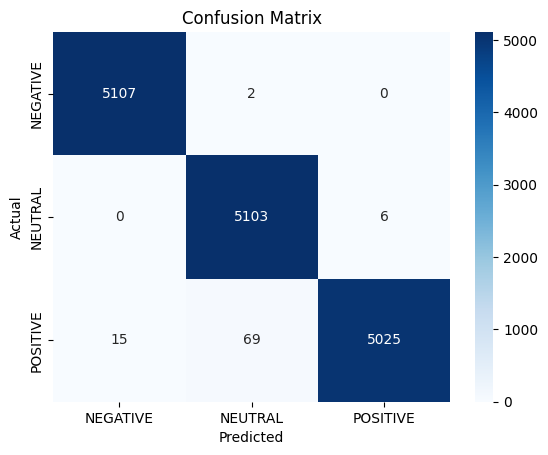

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_distil, y_pred_distil)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels= label_to_id.keys(),
            yticklabels= label_to_id.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### save the model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/distilbert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/distilbert_token")

## Build Bert base model

In [ ]:
model_ckpt = "bert-base-uncased"
config = AutoConfig.from_pretrained(model_ckpt, num_labels=3, id_to_label=id_to_label, label_to_id=label_to_id)

model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config)
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### Train the model

In [ ]:
training_args = TrainingArguments(
    output_dir="./results-bert",
    overwrite_output_dir=True,
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    disable_tqdm=False,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=sentiment_encoded["train"],
    eval_dataset=sentiment_encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

<ipython-input-52-f2b8bbe86e61>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.028400,0.024880,0.994128,0.994121
2,0.013100,0.025017,0.993998,0.993995
3,0.007500,0.027508,0.994911,0.994907


TrainOutput(global_step=2517, training_loss=0.016326121692862072, metrics={'train_runtime': 787.2372, 'train_samples_per_second': 204.426, 'train_steps_per_second': 3.197, 'total_flos': 1.0585842135450624e+16, 'train_loss': 0.016326121692862072, 'epoch': 3.0})

### Evaluate

In [ ]:
# Evaluate
preds_bert = trainer.predict(sentiment_encoded["test"])
preds_bert.metrics

{'test_loss': 0.03817526251077652,
 'test_accuracy': 0.9924969008938475,
 'test_f1': 0.9924884833033254,
 'test_runtime': 24.4246,
 'test_samples_per_second': 627.522,
 'test_steps_per_second': 9.826}

In [ ]:
y_pred_bert = np.argmax(preds_bert.predictions, axis=1)
y_true_bert = sentiment_encoded["test"][:]["labels"]

In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true_bert, y_pred_bert))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5109
           1       0.98      1.00      0.99      5109
           2       1.00      0.98      0.99      5109

    accuracy                           0.99     15327
   macro avg       0.99      0.99      0.99     15327
weighted avg       0.99      0.99      0.99     15327



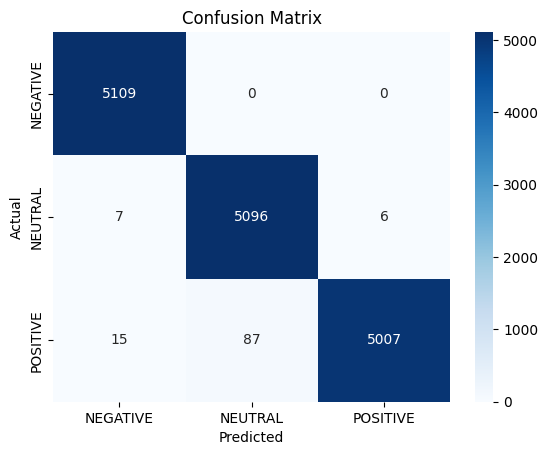

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_bert, y_pred_bert)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels= label_to_id.keys(),
            yticklabels= label_to_id.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Save the model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_token")

('/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_token/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_token/special_tokens_map.json',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_token/vocab.txt',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_token/added_tokens.json',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/bert_token/tokenizer.json')

## Build deberta model

In [ ]:
model_ckpt = "microsoft/deberta-v3-base"

config = AutoConfig.from_pretrained(model_ckpt, num_labels=3, id_to_label=id_to_label, label_to_id=label_to_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


### Train the model

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results-DeBERTa",
    overwrite_output_dir=True,
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    disable_tqdm=False,

)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=sentiment_encoded["train"],
    eval_dataset=sentiment_encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.765500,0.377841,0.867171,0.867660
2,0.372600,0.183115,0.947938,0.947814
3,0.227900,0.136180,0.960334,0.960262


TrainOutput(global_step=2517, training_loss=0.4553066430984152, metrics={'train_runtime': 1057.018, 'train_samples_per_second': 152.251, 'train_steps_per_second': 2.381, 'total_flos': 1.058603197856256e+16, 'train_loss': 0.4553066430984152, 'epoch': 3.0})

### Evaluate

In [ ]:
preds_deberta = trainer.predict(sentiment_encoded["test"])
preds_deberta.metrics

{'test_loss': 0.14187729358673096,
 'test_accuracy': 0.9605924186076857,
 'test_f1': 0.9605373802731038,
 'test_runtime': 31.2244,
 'test_samples_per_second': 490.866,
 'test_steps_per_second': 7.686}

In [ ]:
y_pred_deberta = np.argmax(preds_deberta.predictions, axis=1)
y_true_deberta = sentiment_encoded["test"][:]["labels"]

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_true_deberta, y_pred_deberta))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5109
           1       0.93      0.98      0.95      5109
           2       0.98      0.92      0.95      5109

    accuracy                           0.96     15327
   macro avg       0.96      0.96      0.96     15327
weighted avg       0.96      0.96      0.96     15327



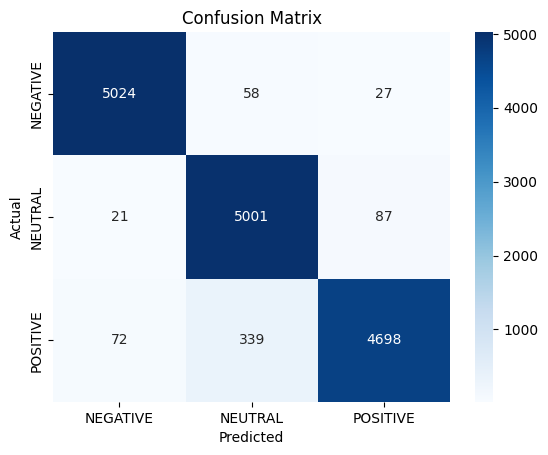

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_deberta, y_pred_deberta)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels= label_to_id.keys(),
            yticklabels= label_to_id.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Save the model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_model")
tokenizer.save_pretrained("/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_token")

('/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_token/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_token/special_tokens_map.json',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_token/spm.model',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_token/added_tokens.json',
 '/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/DeBERTa_token/tokenizer.json')

# Task 2. Product Category Clustering

In [77]:
# Load the dataset again
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Colab Notebooks/week 6/Project NLP/Datafiniti_May19.csv"
df = pd.read_csv(file_path)
df_cp = df.copy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
categories = df_cp['categories'].dropna().unique().tolist()

In [6]:
# Load pre-trained Sentence-BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight and fast model with great performance

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [79]:
# Generate embeddings for the categories
embeddings = model.encode(categories)

In [80]:
# Apply KMeans clustering with 4 clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=0)
cluster_labels = kmeans.fit_predict(embeddings)

In [81]:
cluster_map = defaultdict(list)
for cat, label in zip(categories, cluster_labels):
    cluster_map[label].append(cat)


for label, items in cluster_map.items():
    print(f"\nCluster {label}:")
    for item in items:
        print("  -", item)


Cluster 3:
  - AA,AAA,Health,Electronics,Health & Household,Camcorder Batteries,Camera & Photo,Batteries,Household Batteries,Robot Check,Accessories,Camera Batteries,Health and Beauty,Household Supplies,Batteries & Chargers,Health, Household & Baby Care,Health Personal Care
  - Audio & Video Accessories,TV, Video & Home Audio,Home Audio & Video Accessories,DVD Cases,Electronics,Media Cases & Storage,TV, Video & Audio Accessories,Media Storage & Organization,Disc Storage Wallets,Consumer Electronics,CD, DVD & Blu-ray Discs,Blank Audio/Video Media,Accessories & Supplies,all electronics
  - Stereos,Remote Controls,Audio Docks & Mini Speakers,Kitchen & Dining Features,Home & Tools,Electronics,New Networking,Wireless Speakers,Home, Garage & Office,Portable Speakers,iPod, Audio Player Accessories,Smart Home,Surveillance,Home Improvement,Smart Home & Home Automation Devices,Alarms & Sensors,Amazon Devices,Amazon,Holiday Shop,Kitchen Dining Features,Amazon Echo,Amazon Echo Accessories,Network

In [82]:
category_to_cluster = dict(zip(categories, cluster_labels))
df_cp['category_cluster'] = df_cp['categories'].map(category_to_cluster)

In [83]:
cluster_names = {
    0: 'Fire & Amazon Tablets',
    1: 'eBook Readers & Accessories',
    2: 'Home, Health & Office Essentials',
    3: 'Smart Home & Entertainment Devices'
}

In [84]:
df_cp['meta_category'] = df_cp['category_cluster'].map(cluster_names)

In [85]:
from sklearn.metrics import silhouette_score
score = silhouette_score(embeddings, cluster_labels)
print(f"Silhouette Score: {score}")


Silhouette Score: 0.20637822151184082


In [86]:
df_cp['meta_category'].value_counts()

,count
meta_category,
Fire & Amazon Tablets,14297
Smart Home & Entertainment Devices,12732
eBook Readers & Accessories,1210
"Home, Health & Office Essentials",93


In [87]:
print(df_cp[['name', 'primaryCategories', 'categories', 'meta_category']].sample(5))

                                                    name primaryCategories  \
15435  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...       Electronics   
8176   AmazonBasics AAA Performance Alkaline Batterie...   Health & Beauty   
18772  Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...       Electronics   
19027  Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...       Electronics   
8033   AmazonBasics AAA Performance Alkaline Batterie...   Health & Beauty   

                                              categories  \
15435  Fire Tablets,Computers/Tablets & Networking,Ta...   
8176   AA,AAA,Health,Electronics,Health & Household,C...   
18772  Fire Tablets,Computers/Tablets & Networking,Ta...   
19027  Fire Tablets,Computers/Tablets & Networking,Ta...   
8033   AA,AAA,Health,Electronics,Health & Household,C...   

                            meta_category  
15435               Fire & Amazon Tablets  
8176   Smart Home & Entertainment Devices  
18772               Fire & Amazon Tabl

In [89]:
threshold = 1000
category_counts = df_cp['meta_category'].value_counts()

def merge_small_clusters(df, category_counts, threshold):

    category_merge = {}

    for category, count in category_counts.items():
        if count < threshold:

            max_category = category_counts.idxmax()
            category_merge[category] = max_category
            category_counts[max_category] += count
        else:
            category_merge[category] = category

    df_cp['merged_category'] = df_cp['meta_category'].map(category_merge)
    return df_cp


df_merged = merge_small_clusters(df_cp, category_counts, threshold)

print(df_merged[['meta_category', 'merged_category']].head())

                        meta_category                     merged_category
0  Smart Home & Entertainment Devices  Smart Home & Entertainment Devices
1  Smart Home & Entertainment Devices  Smart Home & Entertainment Devices
2  Smart Home & Entertainment Devices  Smart Home & Entertainment Devices
3  Smart Home & Entertainment Devices  Smart Home & Entertainment Devices
4  Smart Home & Entertainment Devices  Smart Home & Entertainment Devices


In [90]:
new_category_counts = df_merged['merged_category'].value_counts()

print(new_category_counts)

merged_category
Fire & Amazon Tablets                 14390
Smart Home & Entertainment Devices    12732
eBook Readers & Accessories            1210
Name: count, dtype: int64


In [91]:
# Save updated DataFrame if needed
df_merged.to_csv("dataset_with_merged_category.csv", index=False)

# Task 3. Summarize reviews using generative AI

In [101]:
from transformers import BartForConditionalGeneration, BartTokenizer
import torch
# Load pre-trained BART model and tokenizer
model_name = 'facebook/bart-large-cnn'
model = BartForConditionalGeneration.from_pretrained(model_name)
tokenizer = BartTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [102]:
# Summary generation function
def generate_summary(text, max_length=100):
    # If text is NaN or empty, return empty string
    if pd.isnull(text) or text.strip() == "":
        return ""
    # Tokenize input text
    inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True)
    # Generate summary
    summary_ids = model.generate(inputs['input_ids'], max_length=max_length, num_beams=4, length_penalty=2.0, early_stopping=True)
    # Decode summary
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

In [107]:
# Group by merged_category
categories = df_merged['merged_category'].unique()

results = {}

for cat in categories:
    cat_df = df_merged[df_merged['merged_category'] == cat]

    # Top 3 products by rating
    top_products = cat_df.sort_values(by='reviews.rating', ascending=False).head(3)[['name', 'reviews.rating']]

    # Worst product
    worst_product = cat_df.sort_values(by='reviews.rating').head(1)[['name', 'reviews.rating']]

    # Combine all complaints (reviews) for this category
    complaints_text = ' '.join(cat_df[cat_df['reviews.rating'] <= 2]['reviews.text'].dropna().tolist())

    # Generate summary for complaints
    if complaints_text.strip() == "":
      complaints_summary = "No significant complaints for this category."
    else:
      complaints_summary = generate_summary(complaints_text, max_length=150)

    results[cat] = {
        'top_3_products': top_products,
        'worst_product': worst_product,
        'complaints_summary': complaints_summary
    }


In [108]:
for cat, info in results.items():
    print(f"\n📦 Category: {cat}")
    print("⭐ Top 3 Products:")
    print(info['top_3_products'])
    print("\n💔 Worst Product:")
    print(info['worst_product'])
    print("\n📝 Complaints Summary:")
    print(info['complaints_summary'])
    print("-" * 50)


📦 Category: Smart Home & Entertainment Devices
⭐ Top 3 Products:
                                                    name  reviews.rating
25882  AmazonBasics Bluetooth Keyboard for Android De...               5
25880  AmazonBasics Bluetooth Keyboard for Android De...               5
25870  Amazon Fire TV Gaming Edition Streaming Media ...               5

💔 Worst Product:
                                                    name  reviews.rating
11296  AmazonBasics AA Performance Alkaline Batteries...               1

📝 Complaints Summary:
These batteries don't last even in a simple digital clock. Date on the back of these were 1992. Inedible. Battery storage life only lasted 8 months (stored indoors). If it's possible to have gotten a dud batch I sure got it. We BLEW through all these batteries in less than a month.
--------------------------------------------------

📦 Category: Fire & Amazon Tablets
⭐ Top 3 Products:
                                                    name  reviews.ra